# Coeffs from data

In [1]:
import os
import polars as pl
import numpy as np

from scipy.optimize import minimize
import statsmodels.api as sm  # for linear regression

import matplotlib.pyplot as plt

## Load data

Patient demographics by MSOA:

In [2]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [3]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6710.0928,476.4916,450.0672,359.7128,528.488,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,4953.6078,383.4452,513.4716,326.3928,459.0728,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5487.59,432.39,413.22,298.91,469.31,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8193.7557,470.9055,443.5626,371.6609,646.1026,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6516.4218,509.0022,571.242,362.355,564.4212,0.6,0.8


Pick out column names for the health and age proportions:

In [4]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]

In [5]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

SSNAP coefficients:

In [ ]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

admission_props_annual = df_pop_admissions['prob_stroke_given_age'].to_numpy()

admission_props_annual

## Calculate admissions

Calculate from SSNAP coefficients:

In [22]:
admissions_snap_props = sum([
    admission_props_annual[0] * df_stats['age_less65'],
    admission_props_annual[1] * df_stats['age_65'],
    admission_props_annual[2] * df_stats['age_70'],
    admission_props_annual[3] * df_stats['age_75'],
    admission_props_annual[4] * df_stats['age_over80'],
])
df_stats = df_stats.with_columns(pl.Series('admissions_from_ssnap_props', admissions_snap_props))

In [23]:
df_stats['admissions', 'admissions_from_ssnap_props']

admissions,admissions_from_ssnap_props
f64,f64
14.333333,14.423034
7.333333,13.377178
9.333333,12.579268
21.0,16.660679
13.666667,15.765181
…,…
14.333333,13.032092
12.666667,11.970012
16.333333,16.405731


## Scatter results

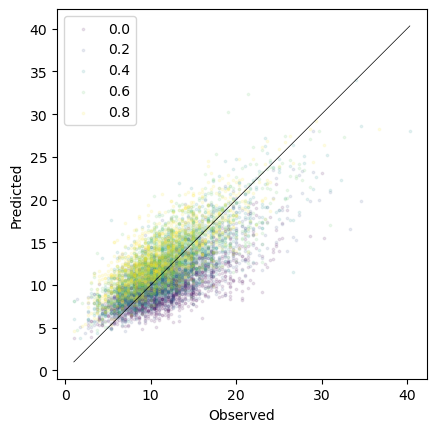

In [24]:
fig, ax = plt.subplots()
zmax = max([df_stats['admissions'].max(), max(df_stats['admissions_from_ssnap_props'])])
zmin = min([df_stats['admissions'].min(), min(df_stats['admissions_from_ssnap_props'])])
ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)

colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, 5))
for q, qmin in enumerate(qmin_list):
    df_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    ax.scatter(df_here['admissions'], df_here['admissions_from_ssnap_props'], s=3, alpha=0.1, color=colours[q], label=qmin)

ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')
ax.legend()

ax.set_aspect('equal')
plt.show()